<img src="images/banner.png" style="width: 100%;">

# Regularization Techniques

**MSDS 2026 | COSCI223: Machine Learning 3**

*Prepared by Kristine Ann M. Carandang*

## Setup

### Modules and Libraries

In [1]:
import os
import numpy as np
import pandas as pd

import keras
from keras import layers
from keras.models import Sequential
from keras import models
from keras import regularizers
from tensorflow import data as tf_data

from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 3})

In [2]:
def plot_history(history):
    """Generate the fitting history plot given the history object from
    model training

    Generates the training and validation accuracy and loss plots.

    Parameters
    ----------
    history : keras History object
        History object returned during model fitting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the generated validation and accuracy loss
        plots
    """
    # Get accuracies and losses from history object
    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    
    # Generate epoch number list
    epochs = range(1, len(accuracy) + 1)

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Plot epochs and accuracy/loss values
    axes[0].plot(epochs, accuracy, 'o', color='tab:blue',
                 label='Train Accuracy')
    axes[0].plot(epochs, val_accuracy, '--', color='tab:blue',
                 label='Validation Accuracy')
    axes[1].plot(epochs, loss, 'o', color='tab:orange', label='Train Loss')
    axes[1].plot(epochs, val_loss, '--', color='tab:orange',
                 label='Validation Loss')

    # Add axis labels and legends
    for ax in axes:
        ax.set_xlabel("Epochs")
        ax.legend()
    axes[0].set_ylabel("Accuracy")
    axes[1].set_ylabel("Loss")
    fig.suptitle("Fitting History Plots", fontsize=16, weight='bold')

    return fig, axes

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

### Cats vs Dogs Dataset

We use this dataset, which is now stored locally under the directory `PetImages`. 

1. Download the raw data

Download the 768M [Cats vs Dogs Dataset](https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip) which is stored in a directory named **`PetImages`**  and contains two subfolders, **`Cat`** and **`Dog`**, containing image files for each category.

In [ ]:
# Download the raw data
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

In [ ]:
# Unzip the directory
!unzip -q kagglecatsanddogs_5340.zip

In [ ]:
# Check the contents of the directory
!ls PetImages

2. Filter out corrupted images

In [ ]:
# Filter out corrupted images
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")

In [ ]:
from PIL import Image

num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for root, _, files in os.walk(folder_path):
        print(root)
        for fname in files:
            path = os.path.join(root, fname)
            try:
                with Image.open(path) as img:
                    img.verify()
            except Exception:
                # print("Removing invalid image:", path)
                os.remove(path)
                num_skipped += 1
            if os.path.getsize(path) == 0:
                # print("Removing empty file:", path)
                os.remove(path)
                num_skipped += 1
                
print(f"Deleted {num_skipped} images.")

In [ ]:
import tensorflow as tf

def clean_dataset_tf(directory):
    num_skipped = 0
    for root, _, files in os.walk(directory):
        for fname in files:
            path = os.path.join(root, fname)

            # Skip if already deleted
            if not os.path.exists(path):
                continue
            try:
                img = tf.io.read_file(path)
                tf.image.decode_jpeg(img, channels=3)  # stricter than decode_image
            except:
                # print("Removing invalid image:", path)
                os.remove(path)
                num_skipped += 1
                continue

            # Check empty files AFTER confirming it exists
            if os.path.exists(path) and os.path.getsize(path) == 0:
                # print("Removing empty file:", path)
                os.remove(path)
                num_skipped += 1
    print(f"Deleted {num_skipped} images.")

clean_dataset_tf("PetImages")

In [ ]:
!find . -name ".DS_Store" -delete
!find . -name "Thumbs.db" -delete

#### Load the dataset

In [4]:
# training parameters
batch_size = 128
n_epochs = 15

In [5]:
# Generate a dataset
image_size = (180, 180)

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)


Found 23438 files belonging to 2 classes.
Using 18751 files for training.
Using 4687 files for validation.


**Visualize the data**

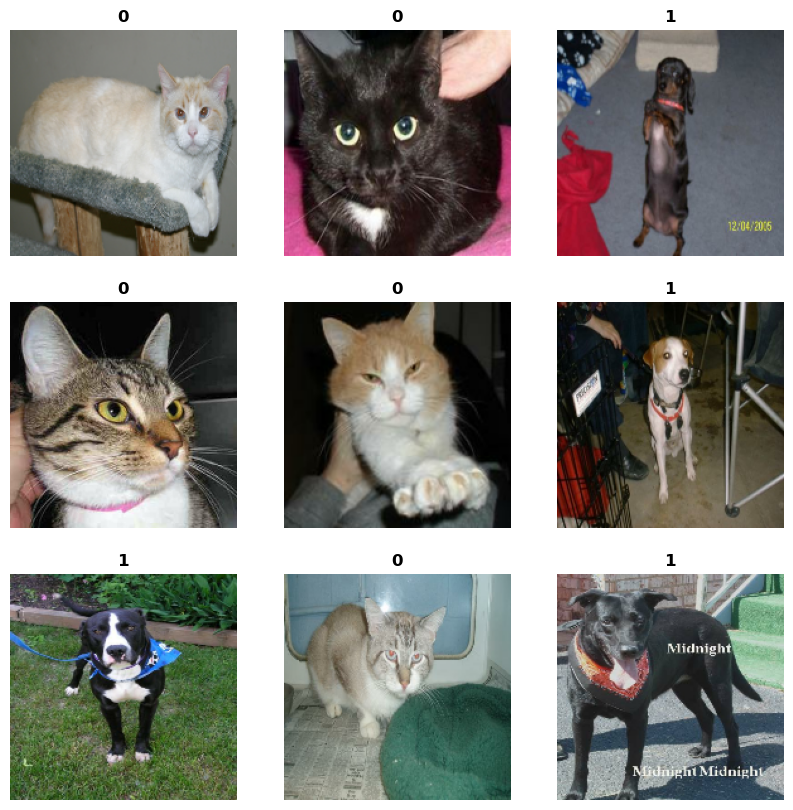

In [6]:
# Visualize the data
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

## Data augmentation

Training a machine learning model on more data leads to better generalization. For small datasets, overfitting will be the main issue.

Data augmentation is another way to fight overfitting when you're working with image data as it increases data diversity and simulating real-world variability. It artificially introduces sample diversity by applying random yet realistic transformations to the training images. It also helps expose the model to different aspects of the training data while slowing down overfitting.

### Types

- [Image augmentation layers available in Keras](https://keras.io/api/layers/preprocessing_layers/image_augmentation/)

Data augmentation can involve geometric or spatial transformations, color transformations, image filtering, and occlusion among others. We show examples of these in this notebook.

#### Sample image

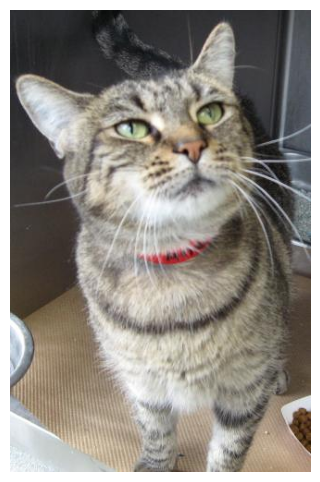

In [7]:
img = keras.utils.load_img("PetImages/Cat/417.jpg")
plt.imshow(img);
plt.axis('off');

#### Geometric or spatial transformation

This type of transformation involve changing the position, shape, or orientation of objects in an image, simulating viewpoint changes, camera motion, and object deformation.

Examples of ways to transform an image include:
- Rotation
- Flip
- Translation
- Zoom
- Crop
- Shear

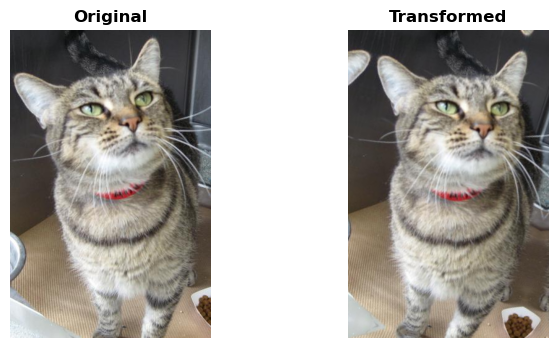

In [8]:
# Define augmentation layer
augment = layers.RandomRotation(0.3)

# Apply augmentation
augmented = augment(img, training=True)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)  
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Transformed")
plt.imshow(augmented.numpy().astype("uint8"))
plt.axis("off")

plt.show()

#### Color transformation

This type of transformation involves changing pixel values, lighting, and color properties, simulating lighting conditions, color shifts, and resolution variability.

Examples to vary include:
- Brightness
- Contrast
- Hue
- Saturation
- Color jitter
- Color degeneration
- Grayscale
- Invert

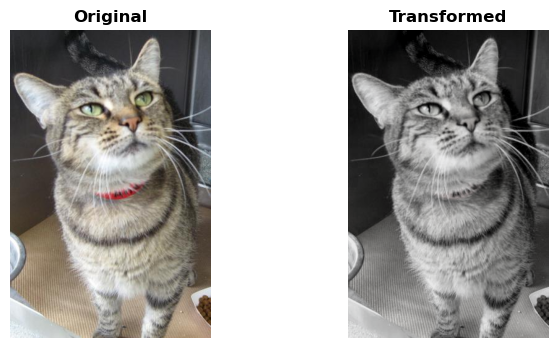

In [9]:
# Define augmentation layer
augment = layers.RandomColorJitter(
    value_range=(0, 255),
    brightness_factor=0.2,
    contrast_factor=0.2,
    saturation_factor=0.2,
    hue_factor=0.1
)

# Apply augmentation
augmented = augment(img, training=True)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)  
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Transformed")
plt.imshow(augmented.numpy().astype("uint8"))
plt.axis("off")

plt.show()

#### Image filtering

This modifies image sharpness or clarity (blur). 

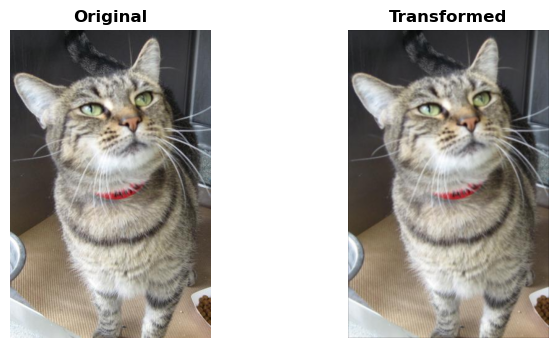

In [10]:
# Define augmentation layer
augment = layers.RandomSharpness(
    factor=(0.3, 0.1),
    value_range=(0, 255)
)

# Apply augmentation
augmented = augment(img, training=True)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)  
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Transformed")
plt.imshow(augmented.numpy().astype("uint8"))
plt.axis("off")

plt.show()

#### Oclussion

This transformation helps the model to be robust to missing or partial information.

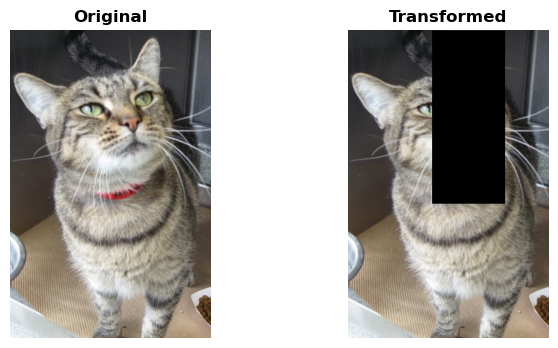

In [11]:
# Define augmentation layer
augment = layers.RandomErasing(
    factor=(0.5, 0.8),
    value_range=(0, 255),
    fill_value=0
)

# Apply augmentation
augmented = augment(img, training=True)

# Plot
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)  
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Transformed")
plt.imshow(augmented.numpy().astype("uint8"))
plt.axis("off")

plt.show()

### Preprocessing approaches

#### Before model training

- *Inside the data pipeline but outside the model*
- Obtain a dataset that yields batches of augmented images.
- Data augmentation is asynchronous, and is buffered before going into the model.

In [12]:
# Define augmentation layers
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# Perform augmentation
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

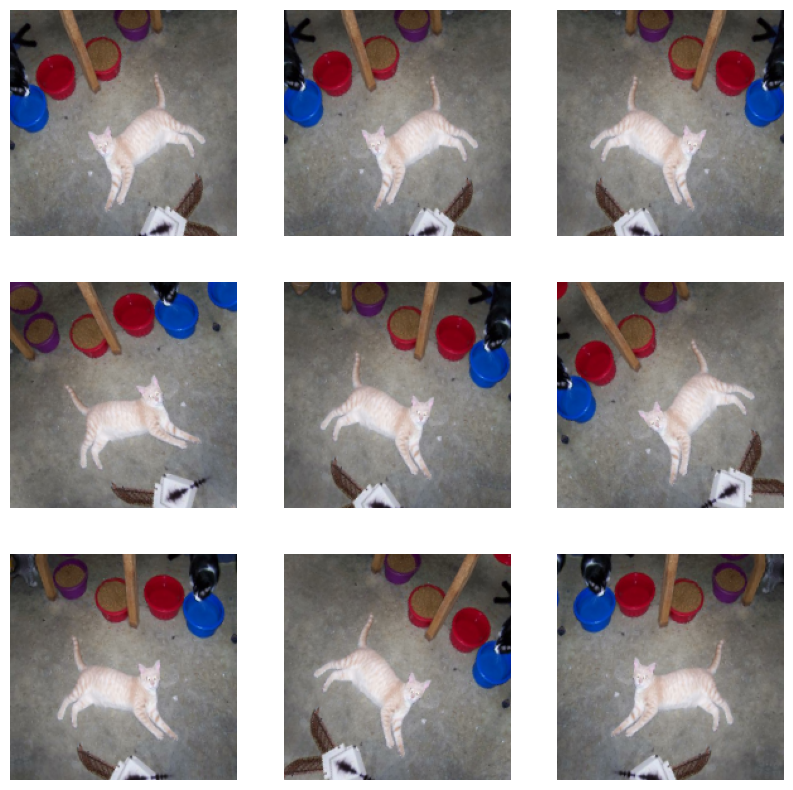

In [13]:
# Visualize augmented samples
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

#### During model training
- *At the start of the model, inside the model*
- Adding image augmentation layer/s to the model such that data augmentation is part of the model.
- Data augmentation happens synchronously with the model execution (happening during `fit()`)but is inactive at test time.

In [14]:
# Include data augmentation layers
model = models.Sequential([
    layers.Input(shape=(180, 180, 3)),

    # Data augmentation layers
    layers.RandomRotation(factor=0.15),
    layers.RandomTranslation(height_factor=0.1,
                             width_factor=0.1),
    layers.RandomFlip(),
    layers.RandomContrast(factor=0.1),

    # Initial blocks
    layers.Conv2D(32, (3, 3),
                        activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3),
                        activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64,
                 activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1,
                 activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_2               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 180, 180, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     7,573,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,593,025 (28.97 MB)

 Trainable params: 7,593,025 (28.97 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Perform the model completion step
model.compile(optimizer='adamax',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Perform model fitting
hx = model.fit(train_ds,
               epochs=n_epochs,
               validation_data=val_ds
                       )

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.5238 - loss: 28.8239 - val_accuracy: 0.5833 - val_loss: 0.6747
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 93s 631ms/step - accuracy: 0.5463 - loss: 0.6843 - val_accuracy: 0.5889 - val_loss: 0.6754
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 93s 630ms/step - accuracy: 0.5712 - loss: 0.6764 - val_accuracy: 0.6019 - val_loss: 0.6655
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 95s 645ms/step - accuracy: 0.5838 - loss: 0.6733 - val_accuracy: 0.6155 - val_loss: 0.6604
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 94s 641ms/step - accuracy: 0.5936 - loss: 0.6686 - val_accuracy: 0.6134 - val_loss: 0.6594
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 95s 644ms/step - accuracy: 0.6103 - loss: 0.6628 - val_accuracy: 0.6335 - val_loss: 0.6512
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 92s 625ms/step - accuracy: 0.6123 - loss: 0.6634 - val_accuracy: 0.6358 - val_loss: 0.6479
Epoch 8/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 91s 619ms/step - accuracy: 0.6222 - loss: 0.

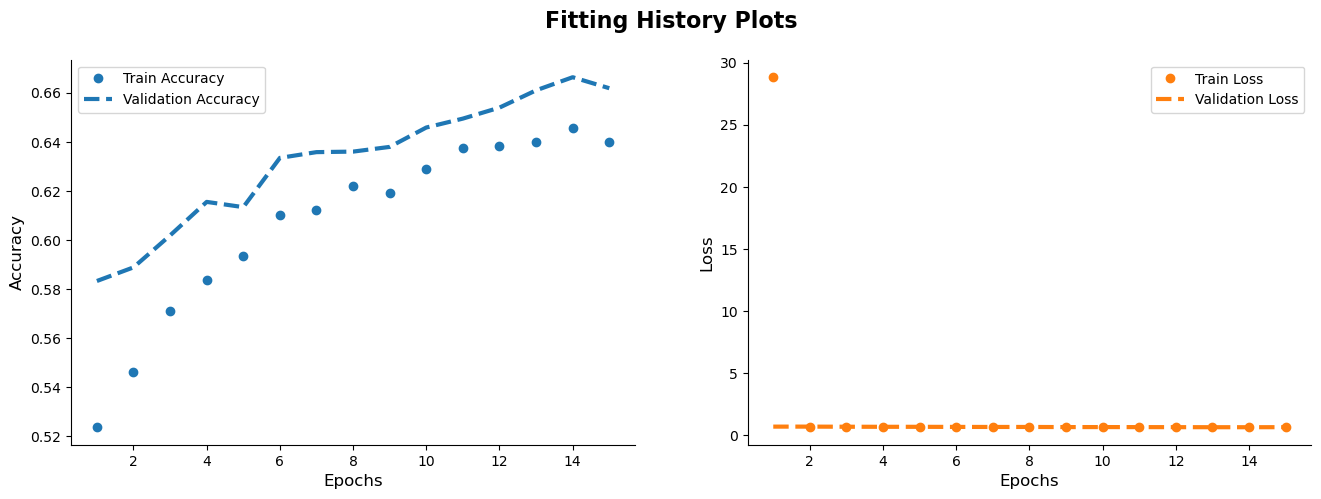

In [16]:
plot_history(hx);

<div class="alert alert-block alert-warning"> 
<b>EXPLORATION TASK</b>
<br>
How did data augmentation affect the model performance?
<br>
</div>

<div class="alert alert-block alert-info"> 
<b>EXPLORATION TASK</b>
<br>
Explore other image augmentation layers, reducing or increasing augmentation layers, or removing dropout layer. Create architecture/s that incorporate these. 
<br>
Don't forget to note what worked and what did not work.
<br>
</div>

In [ ]:
# YOUR CODE HERE

*Insight/s*

## References

- Chollet, F., & Chollet, F. (2021). Deep learning with Python. simon and schuster.
- Bishop, C. M., & Bishop, H. (2023). Deep learning: Foundations and concepts. Springer Nature.
- Goodfellow, I., Bengio, Y., Courville, A., & Bengio, Y. (2016). Deep learning (Vol. 1, No. 2, pp. 1-800). Cambridge: MIT press.
- LeCun et al. (1989). Backpropagation Applied to Handwritten Zip Code Recognition. *Neural Computation* 1(4), pp. 541-551. doi: 10.1162/neco.1989.1.4.541.
- Monterola, CM. ML3 Notebook 2A.
- Simon, J. D. (2024). Understanding Deep Learning.

<img src="images/banner-down.png" style="width: 100%;">